# PART A

In [2]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import seaborn as sns

In [3]:
dataset_path = "448"

print(os.listdir(dataset_path))


['Cracks', 'NonCracks']


In [4]:
crack_path = os.path.join(dataset_path, "Cracks")
noncrack_path = os.path.join(dataset_path, "NonCracks")

crack_images = os.listdir(crack_path)
noncrack_images = os.listdir(noncrack_path)

print("Number of crack images:", len(crack_images))
print("Number of non-crack images:", len(noncrack_images))

Number of crack images: 200
Number of non-crack images: 200


In [5]:
sample_image_name = crack_images[0]

sample_image_path = os.path.join(crack_path, sample_image_name)

print("Image name:", sample_image_name)
print("Image path:", sample_image_path)

Image name: IMG_20180513_164959951_HDR resized_448.jpg
Image path: 448\Cracks\IMG_20180513_164959951_HDR resized_448.jpg


In [6]:
image = cv2.imread(sample_image_path)

print("Image loaded:", image is not None)

Image loaded: True


In [7]:
print("Image shape:", image.shape)

Image shape: (448, 448, 3)


In [8]:
print("Data type:", image.dtype)

Data type: uint8


In [9]:
print("First pixel:", image[0, 0])

First pixel: [102 111 114]


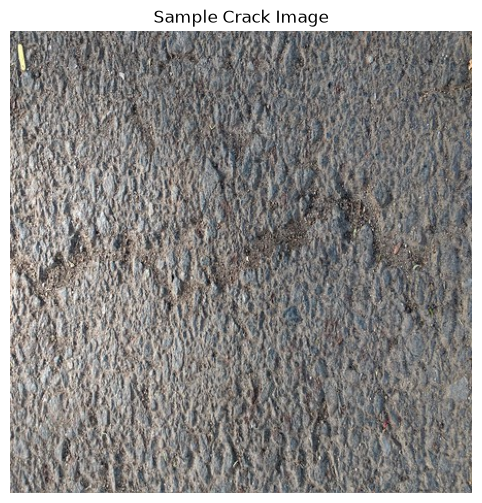

In [10]:
plt.figure(figsize=(6, 6))

plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

plt.title("Sample Crack Image")
plt.axis("off")

plt.show()

In [11]:
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

print("Grayscale shape:", gray_image.shape)
print("Grayscale data type:", gray_image.dtype)

Grayscale shape: (448, 448)
Grayscale data type: uint8


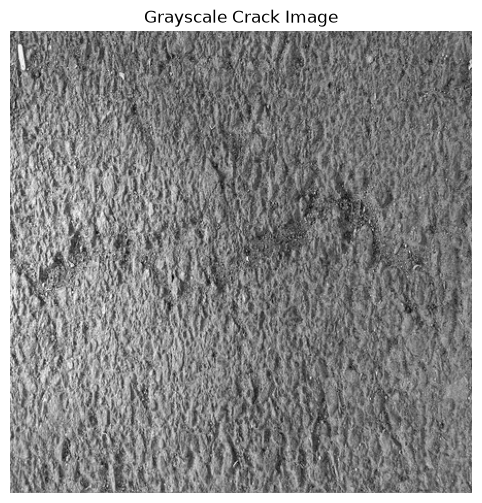

In [12]:
plt.figure(figsize=(6, 6))

plt.imshow(gray_image, cmap="gray")

plt.title("Grayscale Crack Image")
plt.axis("off")

plt.show()

In [13]:
print("First grayscale pixel:", gray_image[0, 0])
print("Minimum intensity:", gray_image.min())
print("Maximum intensity:", gray_image.max())

First grayscale pixel: 111
Minimum intensity: 0
Maximum intensity: 255


In [14]:
mean_brightness = np.mean(gray_image)

print("Mean brightness:", mean_brightness)

Mean brightness: 122.09614656409438


In [15]:
contrast = np.std(gray_image)

print("Contrast:", contrast)

Contrast: 38.01434479318785


In [16]:
dark_threshold = 50

dark_pixels = np.sum(gray_image < dark_threshold)

print("Number of dark pixels:", dark_pixels)

Number of dark pixels: 3278


In [17]:
total_pixels = gray_image.size

print("Total pixels:", total_pixels)

Total pixels: 200704


In [18]:
dark_pixel_ratio = dark_pixels / total_pixels

print("Dark pixel ratio:", dark_pixel_ratio)

Dark pixel ratio: 0.01633250956632653


In [19]:
bright_threshold = 200

bright_pixels = np.sum(gray_image > bright_threshold)

print("Number of bright pixels:", bright_pixels)

Number of bright pixels: 5354


In [20]:
bright_pixel_ratio = bright_pixels / total_pixels

print("Bright pixel ratio:", bright_pixel_ratio)

Bright pixel ratio: 0.02667610012755102


In [21]:
lower_threshold = 50
upper_threshold = 150

edges = cv2.Canny(
    gray_image,
    lower_threshold,
    upper_threshold
)

print("Edge image shape:", edges.shape)
print("Edge image data type:", edges.dtype)

Edge image shape: (448, 448)
Edge image data type: uint8


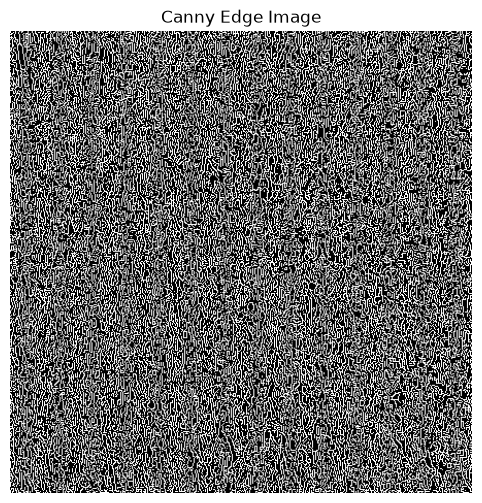

In [22]:
plt.figure(figsize=(6, 6))

plt.imshow(edges, cmap="gray")

plt.title("Canny Edge Image")
plt.axis("off")

plt.show()

In [23]:
edge_count = np.sum(edges == 255)

print("Edge count:", edge_count)

Edge count: 75208


In [24]:
edge_density = edge_count / total_pixels

print("Edge density:", edge_density)

Edge density: 0.37472098214285715


In [25]:
IMAGE_SIZE = (448, 448)

resized_image = cv2.resize(image, IMAGE_SIZE)

print("Original shape:", image.shape)
print("Resized shape:", resized_image.shape)

Original shape: (448, 448, 3)
Resized shape: (448, 448, 3)


In [26]:
def extract_image_features(image_path):
    
    # Read image
    image = cv2.imread(image_path)
    
    # Resize image
    image = cv2.resize(image, IMAGE_SIZE)
    
    # Convert to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    # Intensity features
    mean_brightness = np.mean(gray)
    contrast = np.std(gray)
    
    # Dark pixel ratio
    dark_pixels = np.sum(gray < 50)
    total_pixels = gray.size
    dark_pixel_ratio = dark_pixels / total_pixels
    
    # Bright pixel ratio
    bright_pixels = np.sum(gray > 200)
    bright_pixel_ratio = bright_pixels / total_pixels
    
    # Canny edges
    edges = cv2.Canny(gray, 50, 150)
    
    # Edge features
    edge_count = np.sum(edges == 255)
    edge_density = edge_count / total_pixels
    
    return {
        "mean_brightness": mean_brightness,
        "contrast": contrast,
        "dark_pixel_ratio": dark_pixel_ratio,
        "bright_pixel_ratio": bright_pixel_ratio,
        "edge_count": edge_count,
        "edge_density": edge_density
    }

In [27]:
sample_features = extract_image_features(sample_image_path)

print(sample_features)

{'mean_brightness': np.float64(122.09614656409438), 'contrast': np.float64(38.01434479318785), 'dark_pixel_ratio': np.float64(0.01633250956632653), 'bright_pixel_ratio': np.float64(0.02667610012755102), 'edge_count': np.int64(75208), 'edge_density': np.float64(0.37472098214285715)}


In [28]:
data = []

In [29]:
for image_name in crack_images:
    
    image_path = os.path.join(crack_path, image_name)
    
    features = extract_image_features(image_path)
    
    features["image"] = image_name
    features["label"] = 1
    
    data.append(features)

In [30]:
for image_name in noncrack_images:
    
    image_path = os.path.join(noncrack_path, image_name)
    
    features = extract_image_features(image_path)
    
    features["image"] = image_name
    features["label"] = 0
    
    data.append(features)

In [31]:
df = pd.DataFrame(data)

In [32]:
print("Dataset shape:", df.shape)

Dataset shape: (400, 8)


In [33]:
df.head()

,mean_brightness,contrast,dark_pixel_ratio,bright_pixel_ratio,edge_count,edge_density,image,label
0,122.096147,38.014345,0.016333,0.026676,75208,0.374721,IMG_20180513_164959951_HDR resized_448.jpg,1
1,131.822704,29.319148,0.006741,0.011759,74776,0.372569,IMG_20180513_165129852_HDR resized_448.jpg,1
2,121.171217,35.572563,0.024992,0.020712,72774,0.362594,IMG_20180513_165150613_HDR resized_448.jpg,1
3,130.117701,32.745086,0.008889,0.014917,75745,0.377397,IMG_20180513_165345878_HDR resized_448.jpg,1
4,131.079998,33.199356,0.009741,0.016791,75457,0.375962,IMG_20180513_165349788_HDR resized_448.jpg,1


In [34]:
print(df["label"].value_counts())

label
1    200
0    200
Name: count, dtype: int64


In [35]:
print(df.isnull().sum())

mean_brightness       0
contrast              0
dark_pixel_ratio      0
bright_pixel_ratio    0
edge_count            0
edge_density          0
image                 0
label                 0
dtype: int64


In [36]:
df.describe()

,mean_brightness,contrast,dark_pixel_ratio,bright_pixel_ratio,edge_count,edge_density,label
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,150.873519,32.033602,0.008732,0.084392,72852.160000,0.362983,0.500000
std,17.756517,9.577624,0.019036,0.064557,4106.125248,0.020459,0.500626
min,110.355299,17.144549,0.000000,0.001440,53833.000000,0.268221,0.000000
25%,134.365630,23.670657,0.000005,0.025903,70611.250000,0.351818,0.000000
50%,152.752220,31.847127,0.001308,0.075472,73590.500000,0.366662,0.500000
75%,166.007000,38.952272,0.010578,0.120380,75911.250000,0.378225,1.000000
max,189.694804,63.906473,0.190709,0.302181,78945.000000,0.393340,1.000000


In [37]:
df.groupby("label")[
    [
        "mean_brightness",
        "contrast",
        "dark_pixel_ratio",
        "bright_pixel_ratio",
        "edge_count",
        "edge_density"
    ]
].mean()

,mean_brightness,contrast,dark_pixel_ratio,bright_pixel_ratio,edge_count,edge_density
label,,,,,,
0,157.502980,28.756693,0.003182,0.073852,71600.81,0.356748
1,144.244057,35.310512,0.014283,0.094933,74103.51,0.369218


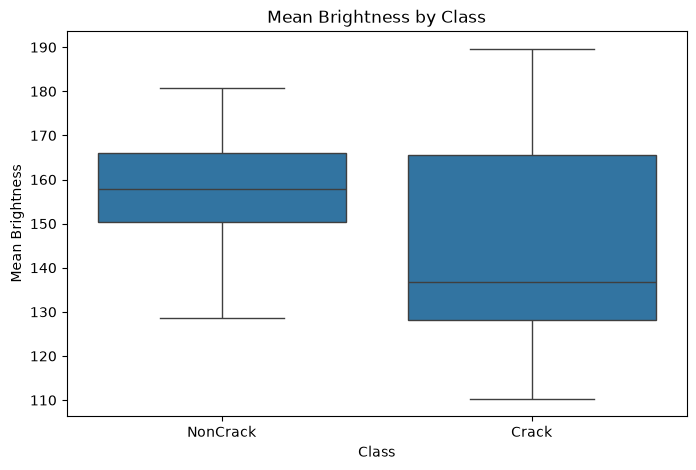

In [38]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="label",
    y="mean_brightness"
)

plt.xticks([0, 1], ["NonCrack", "Crack"])
plt.title("Mean Brightness by Class")
plt.xlabel("Class")
plt.ylabel("Mean Brightness")

plt.show()

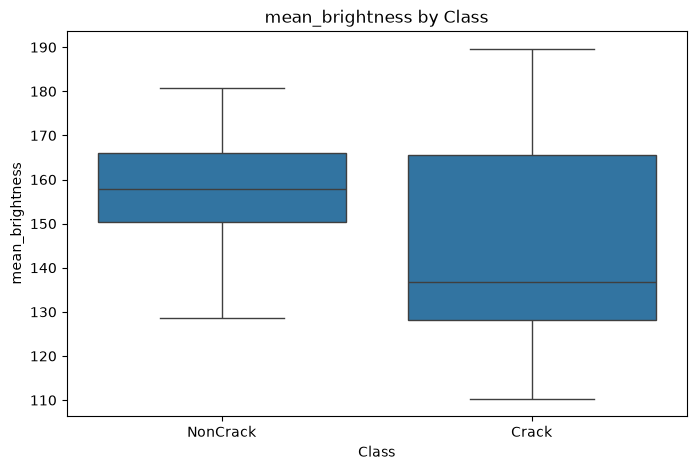

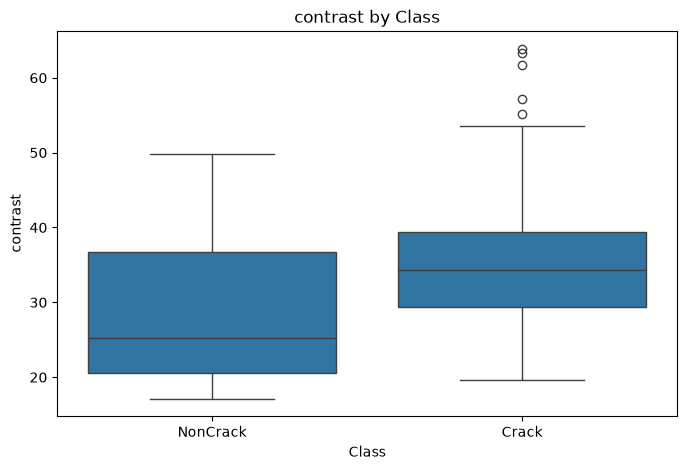

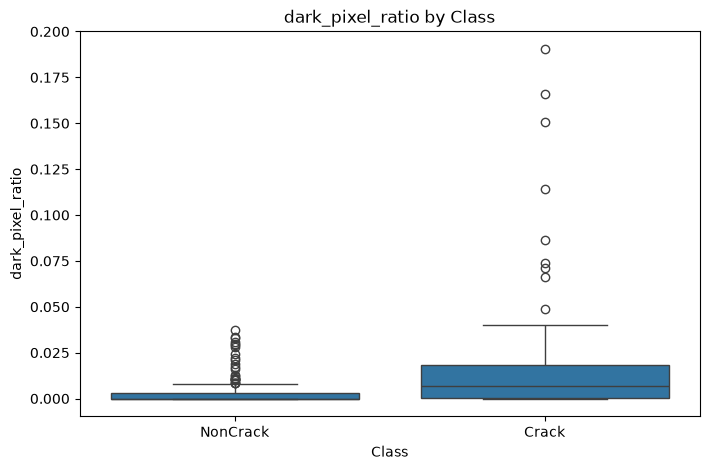

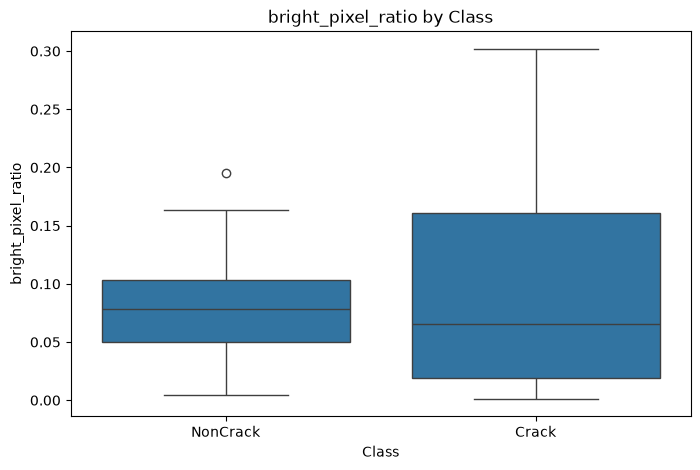

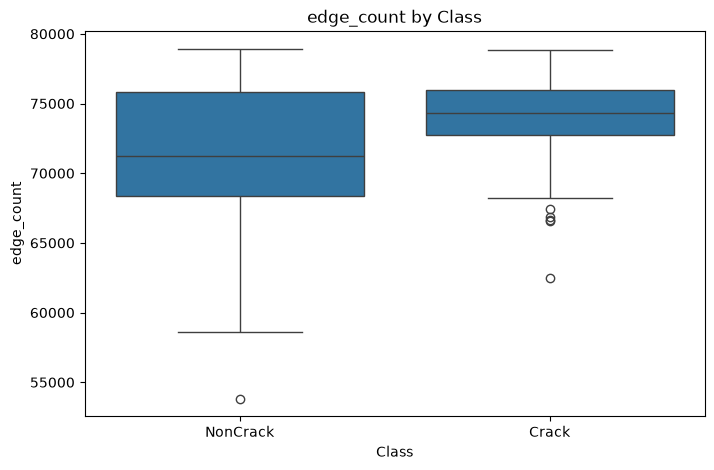

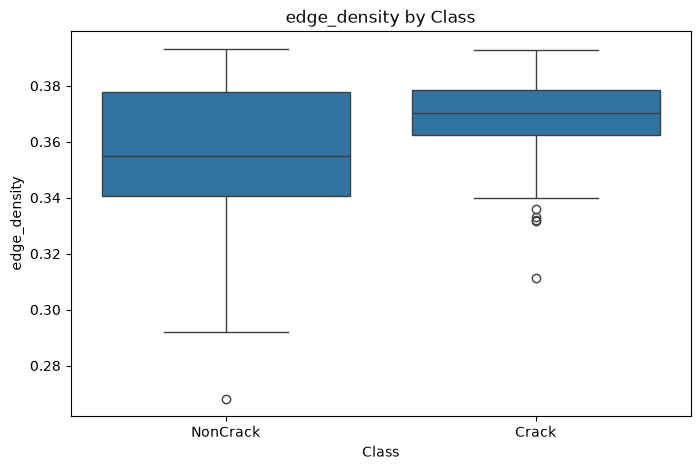

In [39]:
features = [
    "mean_brightness",
    "contrast",
    "dark_pixel_ratio",
    "bright_pixel_ratio",
    "edge_count",
    "edge_density"
]

for feature in features:
    
    plt.figure(figsize=(8, 5))
    
    sns.boxplot(
        data=df,
        x="label",
        y=feature
    )
    
    plt.xticks([0, 1], ["NonCrack", "Crack"])
    plt.title(f"{feature} by Class")
    plt.xlabel("Class")
    plt.ylabel(feature)
    
    plt.show()

In [40]:
feature_columns = [
    "mean_brightness",
    "contrast",
    "dark_pixel_ratio",
    "bright_pixel_ratio",
    "edge_count",
    "edge_density"
]

correlation_matrix = df[feature_columns].corr()

correlation_matrix

,mean_brightness,contrast,dark_pixel_ratio,bright_pixel_ratio,edge_count,edge_density
mean_brightness,1.000000,-0.411311,-0.456492,0.632769,-0.273436,-0.273436
contrast,-0.411311,1.000000,0.619733,0.310130,0.645622,0.645622
dark_pixel_ratio,-0.456492,0.619733,1.000000,-0.022836,0.208467,0.208467
bright_pixel_ratio,0.632769,0.310130,-0.022836,1.000000,0.253987,0.253987
edge_count,-0.273436,0.645622,0.208467,0.253987,1.000000,1.000000
edge_density,-0.273436,0.645622,0.208467,0.253987,1.000000,1.000000


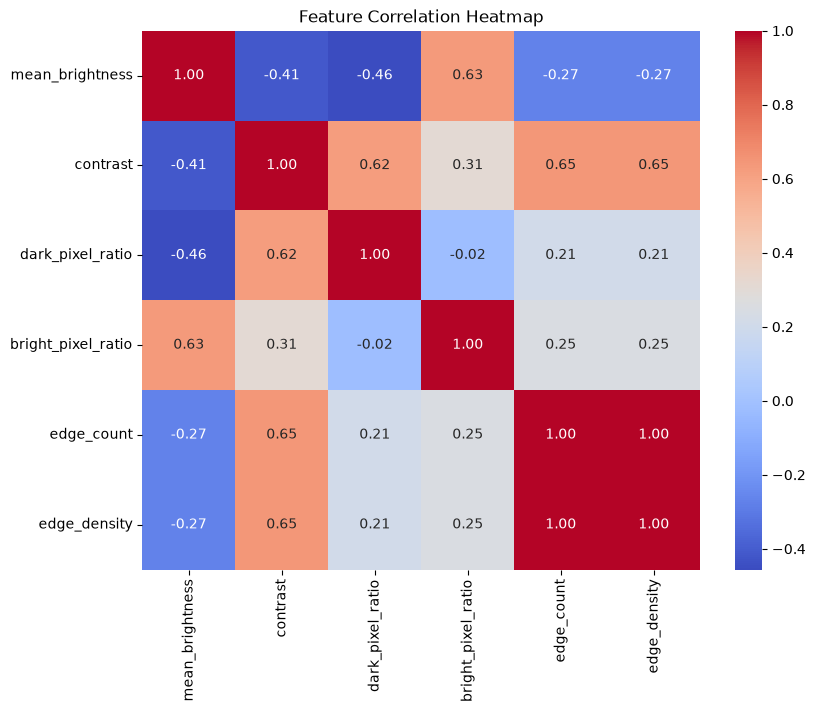

In [41]:
plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Feature Correlation Heatmap")
plt.show()

In [42]:
df[feature_columns + ["label"]].corr()["label"].sort_values()

mean_brightness      -0.373821
bright_pixel_ratio    0.163475
dark_pixel_ratio      0.291940
edge_count            0.305134
edge_density          0.305134
contrast              0.342571
label                 1.000000
Name: label, dtype: float64

In [43]:
X = df[feature_columns]

In [44]:
y = df["label"]

In [45]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (400, 6)
y shape: (400,)


In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [47]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (320, 6)
X_test : (80, 6)
y_train: (320,)
y_test : (80,)


In [48]:
print("Training labels:")
print(y_train.value_counts())

print("\nTesting labels:")
print(y_test.value_counts())

Training labels:
label
1    160
0    160
Name: count, dtype: int64

Testing labels:
label
0    40
1    40
Name: count, dtype: int64


In [49]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(random_state=42))
])

In [50]:
logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['mean_brightness','contrast','dark_pixel_ratio','bright_pixel_ratio', 'edge_count','edge_density']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [51]:
y_pred = logistic_model.predict(X_test)

In [52]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8625


In [53]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=["NonCrack", "Crack"]
))

              precision    recall  f1-score   support

    NonCrack       0.91      0.80      0.85        40
       Crack       0.82      0.93      0.87        40

    accuracy                           0.86        80
   macro avg       0.87      0.86      0.86        80
weighted avg       0.87      0.86      0.86        80



In [54]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[32  8]
 [ 3 37]]


In [55]:
from sklearn.tree import DecisionTreeClassifier

decision_tree = DecisionTreeClassifier(
    random_state=42
)

In [56]:
decision_tree.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [57]:
y_pred_tree = decision_tree.predict(X_test)

In [58]:
from sklearn.metrics import accuracy_score

tree_accuracy = accuracy_score(y_test, y_pred_tree)

print("Decision Tree Accuracy:", tree_accuracy)

Decision Tree Accuracy: 0.8625


In [59]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred_tree,
    target_names=["NonCrack", "Crack"]
))

              precision    recall  f1-score   support

    NonCrack       0.87      0.85      0.86        40
       Crack       0.85      0.88      0.86        40

    accuracy                           0.86        80
   macro avg       0.86      0.86      0.86        80
weighted avg       0.86      0.86      0.86        80



In [60]:
from sklearn.metrics import confusion_matrix

tree_cm = confusion_matrix(y_test, y_pred_tree)

print("Decision Tree Confusion Matrix:")
print(tree_cm)

Decision Tree Confusion Matrix:
[[34  6]
 [ 5 35]]


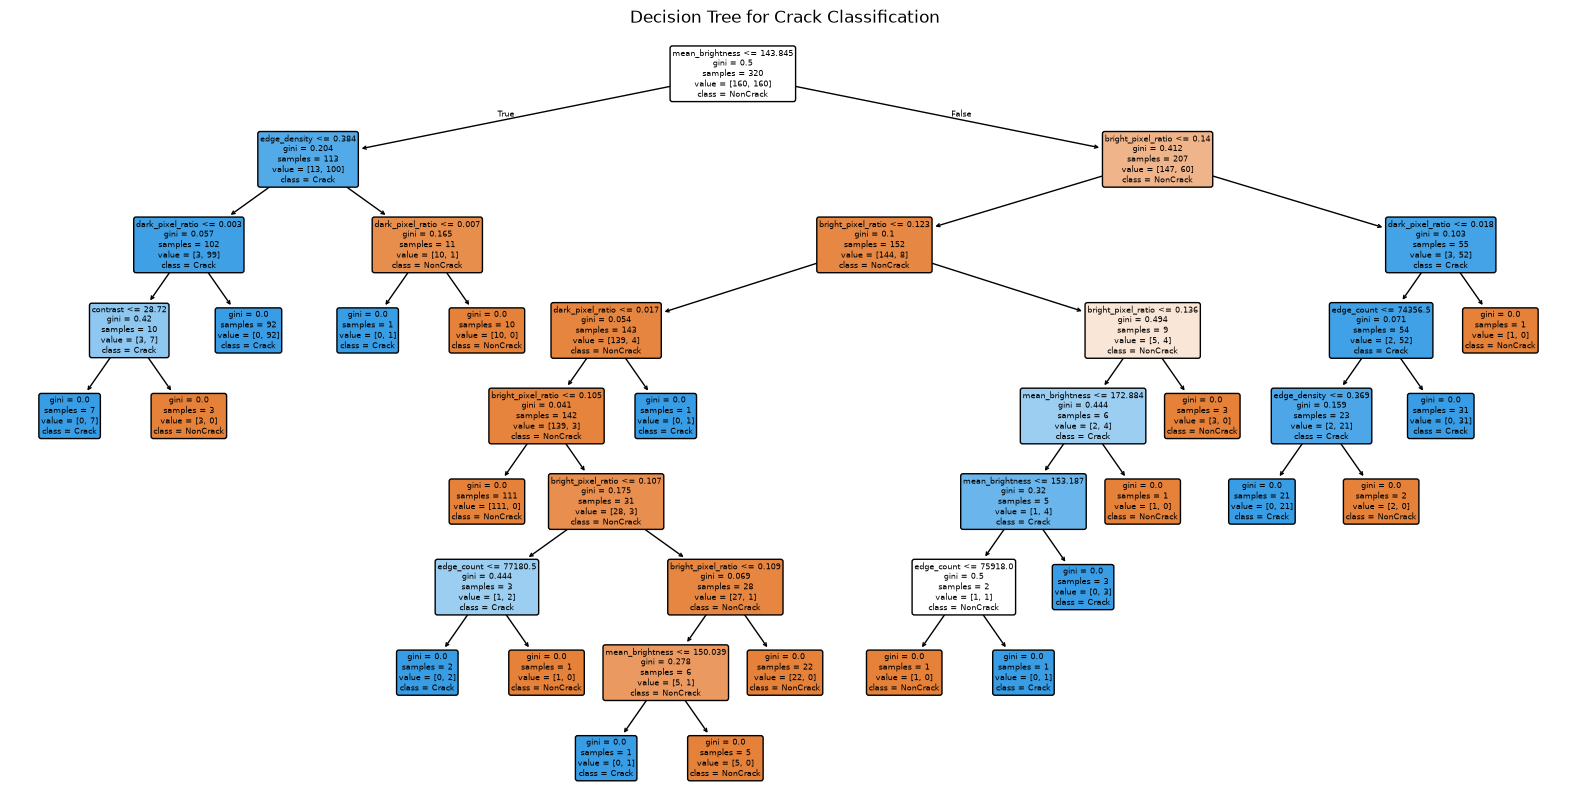

In [61]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))

plot_tree(
    decision_tree,
    feature_names=feature_columns,
    class_names=["NonCrack", "Crack"],
    filled=True,
    rounded=True
)

plt.title("Decision Tree for Crack Classification")
plt.show()

In [62]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

knn_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", KNeighborsClassifier(n_neighbors=5))
])

In [63]:
knn_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['mean_brightness','contrast','dark_pixel_ratio','bright_pixel_ratio', 'edge_count','edge_density']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [64]:
y_pred_knn = knn_model.predict(X_test)

In [65]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

knn_accuracy = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:", knn_accuracy)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_knn,
    target_names=["NonCrack", "Crack"]
))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))

KNN Accuracy: 0.9

Classification Report:
              precision    recall  f1-score   support

    NonCrack       0.86      0.95      0.90        40
       Crack       0.94      0.85      0.89        40

    accuracy                           0.90        80
   macro avg       0.90      0.90      0.90        80
weighted avg       0.90      0.90      0.90        80

Confusion Matrix:
[[38  2]
 [ 6 34]]


In [66]:
k_values = [1, 3, 5, 7, 9, 11, 15]

knn_results = []

for k in k_values:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", KNeighborsClassifier(n_neighbors=k))
    ])
    
    model.fit(X_train, y_train)
    
    predictions = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, predictions)
    
    knn_results.append((k, accuracy))

for k, accuracy in knn_results:
    print(f"K = {k:2d} → Accuracy = {accuracy:.4f}")

K =  1 → Accuracy = 0.9375
K =  3 → Accuracy = 0.9125
K =  5 → Accuracy = 0.9000
K =  7 → Accuracy = 0.8875
K =  9 → Accuracy = 0.9000
K = 11 → Accuracy = 0.8875
K = 15 → Accuracy = 0.8750


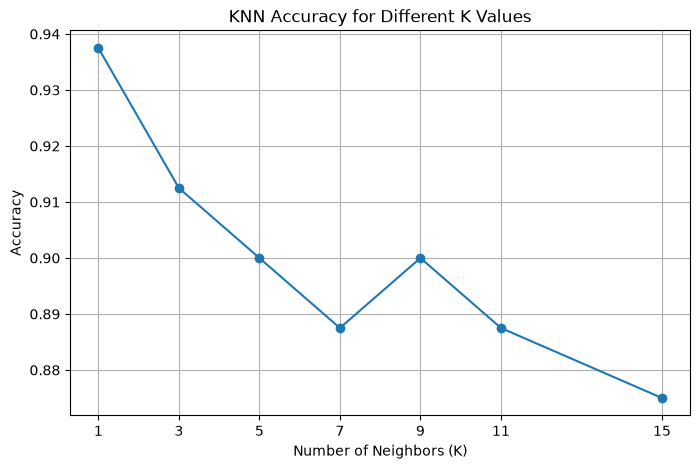

In [67]:
k_values = [1, 3, 5, 7, 9, 11, 15]
accuracies = [accuracy for k, accuracy in knn_results]

plt.figure(figsize=(8, 5))

plt.plot(k_values, accuracies, marker="o")

plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy for Different K Values")
plt.xticks(k_values)
plt.grid(True)

plt.show()

In [68]:
from sklearn.model_selection import cross_val_score

In [69]:
k_values = [1, 3, 5, 7, 9, 11, 15]

cv_results = []

for k in k_values:
    
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", KNeighborsClassifier(n_neighbors=k))
    ])
    
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="accuracy"
    )
    
    cv_results.append({
        "K": k,
        "Mean CV Accuracy": scores.mean(),
        "Std CV Accuracy": scores.std()
    })

cv_results

[{'K': 1,
  'Mean CV Accuracy': np.float64(0.94375),
  'Std CV Accuracy': np.float64(0.025387620014487376)},
 {'K': 3,
  'Mean CV Accuracy': np.float64(0.95625),
  'Std CV Accuracy': np.float64(0.00625)},
 {'K': 5,
  'Mean CV Accuracy': np.float64(0.95),
  'Std CV Accuracy': np.float64(0.022963966338592292)},
 {'K': 7,
  'Mean CV Accuracy': np.float64(0.934375),
  'Std CV Accuracy': np.float64(0.03186887195995491)},
 {'K': 9,
  'Mean CV Accuracy': np.float64(0.925),
  'Std CV Accuracy': np.float64(0.028641098093473996)},
 {'K': 11,
  'Mean CV Accuracy': np.float64(0.921875),
  'Std CV Accuracy': np.float64(0.02614562582918986)},
 {'K': 15,
  'Mean CV Accuracy': np.float64(0.925),
  'Std CV Accuracy': np.float64(0.028641098093473996)}]

In [70]:
best_k_result = max(
    cv_results,
    key=lambda x: x["Mean CV Accuracy"]
)

print("Best K based on 5-fold CV:", best_k_result)

Best K based on 5-fold CV: {'K': 3, 'Mean CV Accuracy': np.float64(0.95625), 'Std CV Accuracy': np.float64(0.00625)}


In [71]:
final_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", KNeighborsClassifier(n_neighbors=3))
])

In [72]:
final_knn.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['mean_brightness','contrast','dark_pixel_ratio','bright_pixel_ratio', 'edge_count','edge_density']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [73]:
final_knn_pred = final_knn.predict(X_test)

In [74]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

final_knn_accuracy = accuracy_score(y_test, final_knn_pred)

print("Final KNN Accuracy:", final_knn_accuracy)

print("\nClassification Report:")
print(classification_report(
    y_test,
    final_knn_pred,
    target_names=["NonCrack", "Crack"]
))

print("Confusion Matrix:")
print(confusion_matrix(y_test, final_knn_pred))

Final KNN Accuracy: 0.9125

Classification Report:
              precision    recall  f1-score   support

    NonCrack       0.90      0.93      0.91        40
       Crack       0.92      0.90      0.91        40

    accuracy                           0.91        80
   macro avg       0.91      0.91      0.91        80
weighted avg       0.91      0.91      0.91        80

Confusion Matrix:
[[37  3]
 [ 4 36]]


In [75]:
results = {
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "KNN (K=3)"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        tree_accuracy,
        final_knn_accuracy
    ]
}

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy
0,Logistic Regression,0.8625
1,Decision Tree,0.8625
2,KNN (K=3),0.9125


# PART B

In [76]:
import pandas as pd

emails = pd.read_csv("emails.csv")

emails.head()

,Email No.,the,to,ect,and,for,of,a,you,hou,...,connevey,jay,valued,lay,infrastructure,military,allowing,ff,dry,Prediction
0,Email 1,0,0,1,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Email 2,8,13,24,6,6,2,102,1,27,...,0,0,0,0,0,0,0,1,0,0
2,Email 3,0,0,1,0,0,0,8,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Email 4,0,5,22,0,5,1,51,2,10,...,0,0,0,0,0,0,0,0,0,0
4,Email 5,7,6,17,1,5,2,57,0,9,...,0,0,0,0,0,0,0,1,0,0


In [77]:
print("Dataset shape:", emails.shape)

print("\nColumns:")
print(emails.columns.tolist())

print("\nFirst 5 rows:")
display(emails.head())

Dataset shape: (5172, 3002)

Columns:
['Email No.', 'the', 'to', 'ect', 'and', 'for', 'of', 'a', 'you', 'hou', 'in', 'on', 'is', 'this', 'enron', 'i', 'be', 'that', 'will', 'have', 'with', 'your', 'at', 'we', 's', 'are', 'it', 'by', 'com', 'as', 'from', 'gas', 'or', 'not', 'me', 'deal', 'if', 'meter', 'hpl', 'please', 're', 'e', 'any', 'our', 'corp', 'can', 'd', 'all', 'has', 'was', 'know', 'need', 'an', 'forwarded', 'new', 't', 'may', 'up', 'j', 'mmbtu', 'should', 'do', 'am', 'get', 'out', 'see', 'no', 'there', 'price', 'daren', 'but', 'been', 'company', 'l', 'these', 'let', 'so', 'would', 'm', 'into', 'xls', 'farmer', 'attached', 'us', 'information', 'they', 'message', 'day', 'time', 'my', 'one', 'what', 'only', 'http', 'th', 'volume', 'mail', 'contract', 'which', 'month', 'more', 'robert', 'sitara', 'about', 'texas', 'nom', 'energy', 'pec', 'questions', 'www', 'deals', 'volumes', 'pm', 'ena', 'now', 'their', 'file', 'some', 'email', 'just', 'also', 'call', 'change', 'other', 'here',

,Email No.,the,to,ect,and,for,of,a,you,hou,...,connevey,jay,valued,lay,infrastructure,military,allowing,ff,dry,Prediction
0,Email 1,0,0,1,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Email 2,8,13,24,6,6,2,102,1,27,...,0,0,0,0,0,0,0,1,0,0
2,Email 3,0,0,1,0,0,0,8,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Email 4,0,5,22,0,5,1,51,2,10,...,0,0,0,0,0,0,0,0,0,0
4,Email 5,7,6,17,1,5,2,57,0,9,...,0,0,0,0,0,0,0,1,0,0


In [78]:
print("\nMissing values:")
print(emails.isnull().sum())


Missing values:
Email No.     0
the           0
to            0
ect           0
and           0
             ..
military      0
allowing      0
ff            0
dry           0
Prediction    0
Length: 3002, dtype: int64


In [79]:
print("Prediction values:")
print(emails["Prediction"].value_counts())

print("\nPrediction percentages:")
print(emails["Prediction"].value_counts(normalize=True) * 100)

Prediction values:
Prediction
0    3672
1    1500
Name: count, dtype: int64

Prediction percentages:
Prediction
0    70.99768
1    29.00232
Name: proportion, dtype: float64


In [80]:
print("Number of rows:", len(emails))
print("Number of features:", emails.shape[1] - 2)

Number of rows: 5172
Number of features: 3000


In [81]:
X = emails.drop(columns=["Email No.", "Prediction"])
y = emails["Prediction"]

In [82]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5172, 3000)
y shape: (5172,)


In [83]:
from sklearn.model_selection import train_test_split

X_train_text, X_test_text, y_train_text, y_test_text = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [84]:
print("X_train:", X_train_text.shape)
print("X_test :", X_test_text.shape)

print("\nTraining labels:")
print(y_train_text.value_counts())

print("\nTesting labels:")
print(y_test_text.value_counts())

X_train: (4137, 3000)
X_test : (1035, 3000)

Training labels:
Prediction
0    2937
1    1200
Name: count, dtype: int64

Testing labels:
Prediction
0    735
1    300
Name: count, dtype: int64


In [85]:
from sklearn.linear_model import LogisticRegression

text_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

text_model.fit(X_train_text, y_train_text)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [86]:
y_pred_text = text_model.predict(X_test_text)

In [87]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

text_accuracy = accuracy_score(
    y_test_text,
    y_pred_text
)

print("Text Classification Accuracy:", text_accuracy)

print("\nClassification Report:")
print(classification_report(
    y_test_text,
    y_pred_text,
    target_names=["Non-Spam", "Spam"]
))

print("Confusion Matrix:")
print(confusion_matrix(
    y_test_text,
    y_pred_text
))

Text Classification Accuracy: 0.9826086956521739

Classification Report:
              precision    recall  f1-score   support

    Non-Spam       0.99      0.98      0.99       735
        Spam       0.96      0.98      0.97       300

    accuracy                           0.98      1035
   macro avg       0.98      0.98      0.98      1035
weighted avg       0.98      0.98      0.98      1035

Confusion Matrix:
[[722  13]
 [  5 295]]


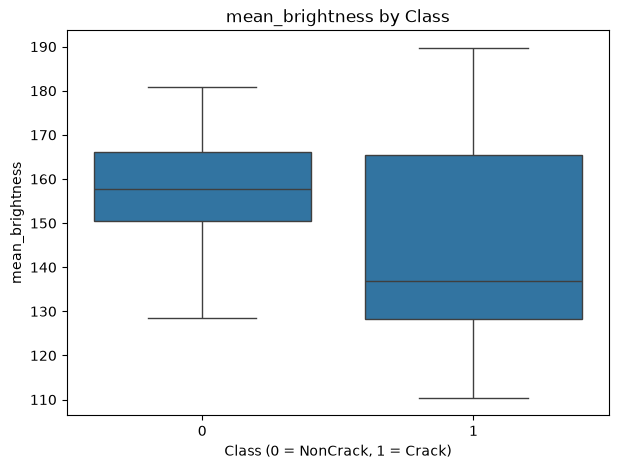

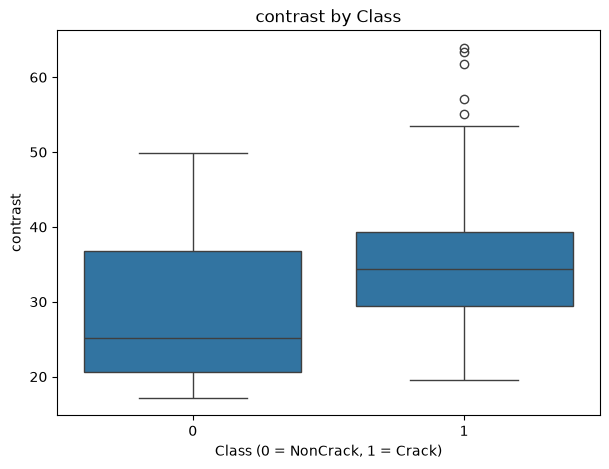

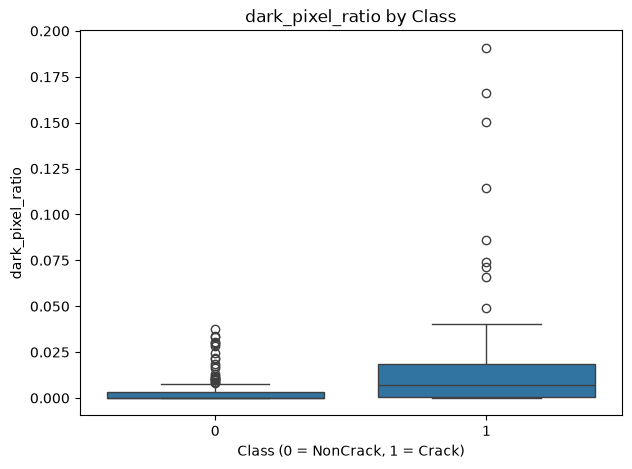

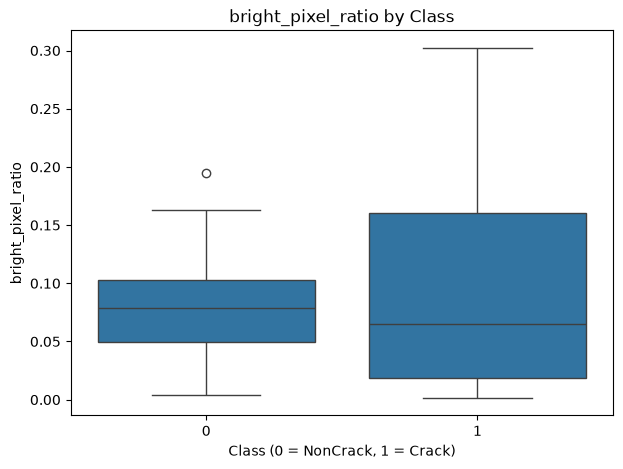

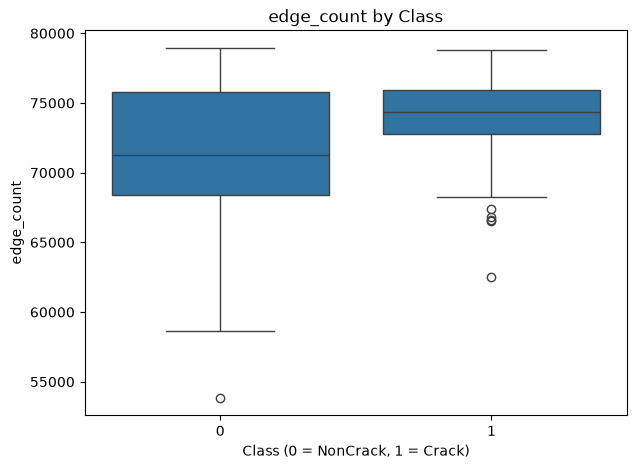

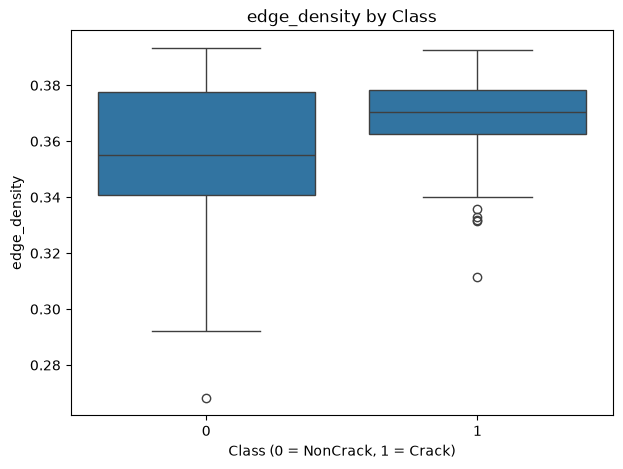

In [88]:
import matplotlib.pyplot as plt
import seaborn as sns

features = [
    "mean_brightness",
    "contrast",
    "dark_pixel_ratio",
    "bright_pixel_ratio",
    "edge_count",
    "edge_density"
]

for feature in features:
    plt.figure(figsize=(7, 5))
    
    sns.boxplot(
        data=df,
        x="label",
        y=feature
    )
    
    plt.title(f"{feature} by Class")
    plt.xlabel("Class (0 = NonCrack, 1 = Crack)")
    plt.ylabel(feature)
    
    plt.show()

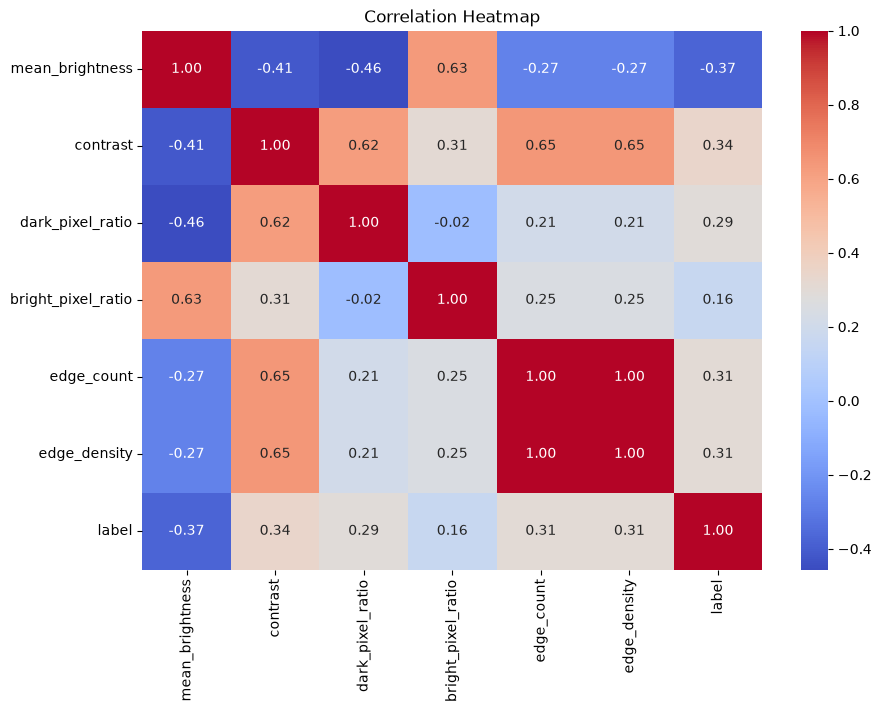

In [89]:
plt.figure(figsize=(10, 7))

corr = df[
    features + ["label"]
].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

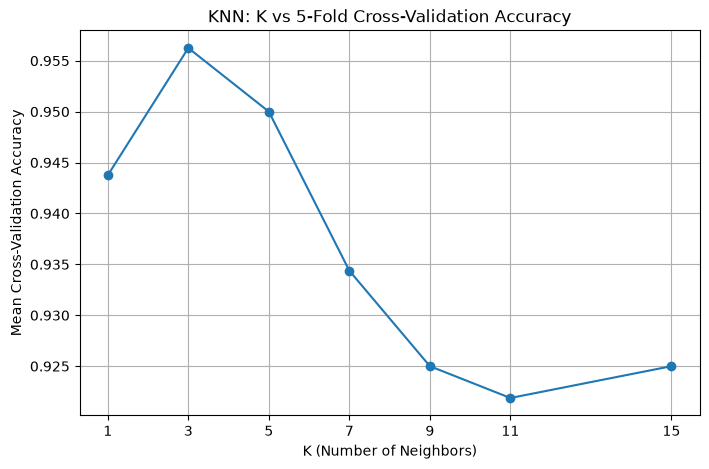

In [90]:
k_values = [result["K"] for result in cv_results]
cv_accuracies = [
    result["Mean CV Accuracy"]
    for result in cv_results
]

plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    cv_accuracies,
    marker="o"
)

plt.xlabel("K (Number of Neighbors)")
plt.ylabel("Mean Cross-Validation Accuracy")
plt.title("KNN: K vs 5-Fold Cross-Validation Accuracy")
plt.xticks(k_values)
plt.grid(True)

plt.show()

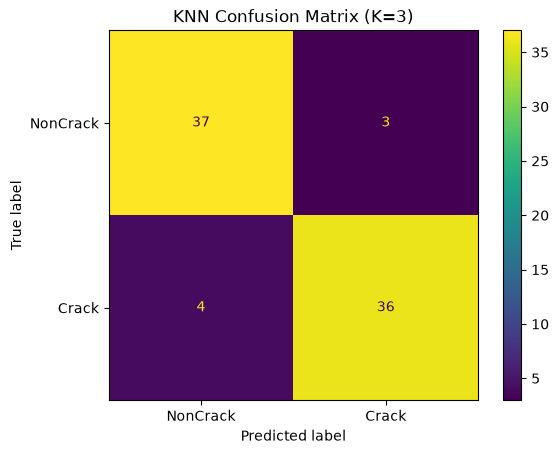

In [91]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    final_knn_pred,
    display_labels=["NonCrack", "Crack"]
)

plt.title("KNN Confusion Matrix (K=3)")
plt.show()

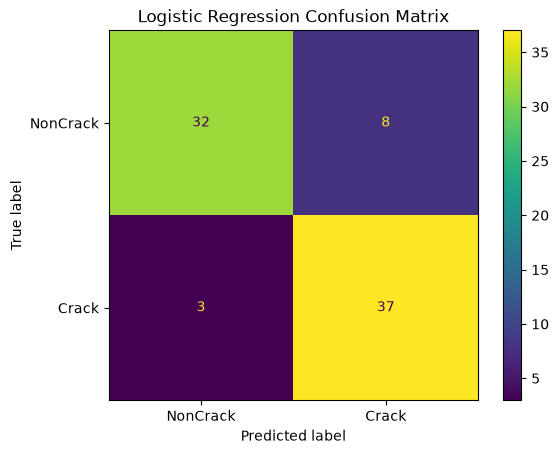

In [92]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["NonCrack", "Crack"]
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

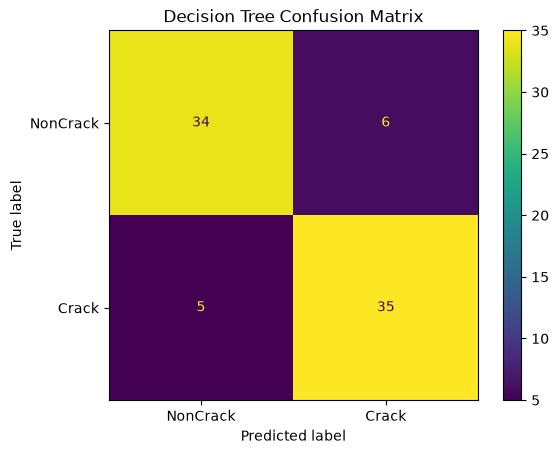

In [93]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_tree,
    display_labels=["NonCrack", "Crack"]
)

plt.title("Decision Tree Confusion Matrix")
plt.show()

# PART C

In [96]:
# Modified Canny thresholds
lower_threshold_new = 30
upper_threshold_new = 100

improved_features = []

for label, folder in [(1, "Cracks"), (0, "NonCracks")]:
    
    folder_path = os.path.join("448", folder)
    
    for filename in os.listdir(folder_path):
        
        image_path = os.path.join(folder_path, filename)
        
        # Load image
        image = cv2.imread(image_path)
        
        # Skip files that OpenCV cannot read
        if image is None:
            continue
        
        # Convert to grayscale
        gray_image = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2GRAY
        )
        
        # Apply modified Canny
        edges_new = cv2.Canny(
            gray_image,
            lower_threshold_new,
            upper_threshold_new
        )
        
        # Calculate edge features
        edge_count_new = np.sum(edges_new > 0)
        edge_density_new = edge_count_new / edges_new.size
        
        improved_features.append({
            "edge_count_new": edge_count_new,
            "edge_density_new": edge_density_new,
            "label": label
        })

improved_edge_df = pd.DataFrame(improved_features)

print("Improved feature dataset shape:",
      improved_edge_df.shape)

display(improved_edge_df.head())

Improved feature dataset shape: (400, 3)


,edge_count_new,edge_density_new,label
0,75803,0.377686,1
1,76141,0.379370,1
2,75006,0.373715,1
3,76553,0.381422,1
4,76277,0.380047,1


In [97]:
df_improved = df.copy()

df_improved["edge_count"] = improved_edge_df["edge_count_new"]
df_improved["edge_density"] = improved_edge_df["edge_density_new"]

print("Improved dataset shape:", df_improved.shape)

display(df_improved.head())

Improved dataset shape: (400, 8)


,mean_brightness,contrast,dark_pixel_ratio,bright_pixel_ratio,edge_count,edge_density,image,label
0,122.096147,38.014345,0.016333,0.026676,75803,0.377686,IMG_20180513_164959951_HDR resized_448.jpg,1
1,131.822704,29.319148,0.006741,0.011759,76141,0.379370,IMG_20180513_165129852_HDR resized_448.jpg,1
2,121.171217,35.572563,0.024992,0.020712,75006,0.373715,IMG_20180513_165150613_HDR resized_448.jpg,1
3,130.117701,32.745086,0.008889,0.014917,76553,0.381422,IMG_20180513_165345878_HDR resized_448.jpg,1
4,131.079998,33.199356,0.009741,0.016791,76277,0.380047,IMG_20180513_165349788_HDR resized_448.jpg,1


In [98]:
print(df_improved["label"].value_counts())

label
1    200
0    200
Name: count, dtype: int64


In [99]:
X_improved = df_improved[features]
y_improved = df_improved["label"]

print("X improved shape:", X_improved.shape)
print("y improved shape:", y_improved.shape)

X improved shape: (400, 6)
y improved shape: (400,)


In [100]:
X_train_imp, X_test_imp, y_train_imp, y_test_imp = train_test_split(
    X_improved,
    y_improved,
    test_size=0.20,
    random_state=42,
    stratify=y_improved
)

print("X_train:", X_train_imp.shape)
print("X_test :", X_test_imp.shape)

X_train: (320, 6)
X_test : (80, 6)


In [101]:
improved_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=3))
])

improved_knn.fit(
    X_train_imp,
    y_train_imp
)

y_pred_improved = improved_knn.predict(
    X_test_imp
)

In [102]:
improved_accuracy = accuracy_score(
    y_test_imp,
    y_pred_improved
)

print("Improved KNN Accuracy:", improved_accuracy)

print("\nClassification Report:")
print(
    classification_report(
        y_test_imp,
        y_pred_improved,
        target_names=["NonCrack", "Crack"]
    )
)

print("Confusion Matrix:")
print(
    confusion_matrix(
        y_test_imp,
        y_pred_improved
    )
)

Improved KNN Accuracy: 0.9125

Classification Report:
              precision    recall  f1-score   support

    NonCrack       0.90      0.93      0.91        40
       Crack       0.92      0.90      0.91        40

    accuracy                           0.91        80
   macro avg       0.91      0.91      0.91        80
weighted avg       0.91      0.91      0.91        80

Confusion Matrix:
[[37  3]
 [ 4 36]]


## Part C — Improving the Image Representation

To investigate whether the image representation could be improved, the Canny edge detection thresholds were modified.

### Original representation

The original Canny thresholds were:

- Lower threshold = 50
- Upper threshold = 150

### Modified representation

The thresholds were changed to:

- Lower threshold = 30
- Upper threshold = 100

Lower thresholds make the Canny detector more sensitive to weaker intensity changes. This may capture additional fine structures, but it can also introduce additional edges caused by surface texture or noise.

The remaining four image features and the KNN classifier were kept unchanged so that the effect of the representation change could be evaluated independently.

In [103]:
comparison = pd.DataFrame({
    "Approach": [
        "Original",
        "Modified"
    ],
    "Canny Thresholds": [
        "(50, 150)",
        "(30, 100)"
    ],
    "K": [
        3,
        3
    ],
    "Accuracy": [
        0.9125,
        improved_accuracy
    ]
})

comparison["Accuracy (%)"] = comparison["Accuracy"] * 100

comparison

,Approach,Canny Thresholds,K,Accuracy,Accuracy (%)
0,Original,"(50, 150)",3,0.9125,91.25
1,Modified,"(30, 100)",3,0.9125,91.25


In [104]:
original_accuracy = 0.9125

accuracy_change = improved_accuracy - original_accuracy

print("Original Accuracy :", original_accuracy)
print("Modified Accuracy :", improved_accuracy)
print("Change in Accuracy:", accuracy_change)
print("Change in Percentage Points:", accuracy_change * 100)

Original Accuracy : 0.9125
Modified Accuracy : 0.9125
Change in Accuracy: 0.0
Change in Percentage Points: 0.0


In [105]:
print("Original edge features:")
display(
    df[["edge_count", "edge_density"]].describe()
)

print("\nModified edge features:")
display(
    df_improved[["edge_count", "edge_density"]].describe()
)

Original edge features:


,edge_count,edge_density
count,400.000000,400.000000
mean,72852.160000,0.362983
std,4106.125248,0.020459
min,53833.000000,0.268221
25%,70611.250000,0.351818
50%,73590.500000,0.366662
75%,75911.250000,0.378225
max,78945.000000,0.393340



Modified edge features:


,edge_count,edge_density
count,400.000000,400.000000
mean,75048.607500,0.373927
std,2305.856927,0.011489
min,67458.000000,0.336107
25%,73741.000000,0.367412
50%,75271.000000,0.375035
75%,76629.250000,0.381802
max,79182.000000,0.394521


### Part C — Observation and Conclusion

The Canny edge representation was modified by changing the thresholds from (50, 150) to (30, 100).

The modified thresholds produced a different edge representation by making the edge detector more sensitive to weaker intensity changes.

However, when the modified features were used with the same KNN model (K = 3), the test accuracy remained unchanged:

- Original approach: 91.25%
- Modified approach: 91.25%
- Change: 0 percentage points

The confusion matrix also remained the same:

[[37, 3],
 [4, 36]]

Therefore, the modified Canny representation did not improve the classification accuracy for this dataset and train-test split.

This experiment shows that changing the image representation does not necessarily improve model performance. A representation may change substantially while producing the same classification decisions.

# COMPUTATIONAL PERFORMANCE COMPARISON

In [111]:
from sklearn.linear_model import LogisticRegression
import time

lr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic", LogisticRegression(max_iter=1000))
])

start_time = time.perf_counter()

lr_model.fit(X_train, y_train)

training_time_lr = time.perf_counter() - start_time


start_time = time.perf_counter()

lr_pred = lr_model.predict(X_test)

prediction_time_lr = time.perf_counter() - start_time


lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression")
print("Training time :", training_time_lr, "seconds")
print("Prediction time:", prediction_time_lr, "seconds")
print("Accuracy       :", lr_accuracy)

Logistic Regression
Training time : 0.008769799999981842 seconds
Prediction time: 0.0031025000000681757 seconds
Accuracy       : 0.8625


In [112]:
from sklearn.tree import DecisionTreeClassifier

tree_model = Pipeline([
    ("scaler", StandardScaler()),
    ("tree", DecisionTreeClassifier(random_state=42))
])

start_time = time.perf_counter()

tree_model.fit(X_train, y_train)

training_time_tree = time.perf_counter() - start_time


start_time = time.perf_counter()

tree_pred = tree_model.predict(X_test)

prediction_time_tree = time.perf_counter() - start_time


tree_accuracy = accuracy_score(y_test, tree_pred)

print("Decision Tree")
print("Training time :", training_time_tree, "seconds")
print("Prediction time:", prediction_time_tree, "seconds")
print("Accuracy       :", tree_accuracy)

Decision Tree
Training time : 0.007131999999955951 seconds
Prediction time: 0.0015123000000585307 seconds
Accuracy       : 0.8625


In [113]:
knn_model = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=3))
])

start_time = time.perf_counter()

knn_model.fit(X_train, y_train)

training_time_knn = time.perf_counter() - start_time


start_time = time.perf_counter()

knn_pred = knn_model.predict(X_test)

prediction_time_knn = time.perf_counter() - start_time


knn_accuracy = accuracy_score(y_test, knn_pred)

print("KNN (K=3)")
print("Training time :", training_time_knn, "seconds")
print("Prediction time:", prediction_time_knn, "seconds")
print("Accuracy       :", knn_accuracy)

KNN (K=3)
Training time : 0.005624500000067201 seconds
Prediction time: 0.0032615000000078 seconds
Accuracy       : 0.9125


In [114]:
performance_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "KNN (K=3)"
    ],
    "Accuracy": [
        lr_accuracy,
        tree_accuracy,
        knn_accuracy
    ],
    "Training Time (s)": [
        training_time_lr,
        training_time_tree,
        training_time_knn
    ],
    "Prediction Time (s)": [
        prediction_time_lr,
        prediction_time_tree,
        prediction_time_knn
    ]
})

performance_comparison["Accuracy (%)"] = (
    performance_comparison["Accuracy"] * 100
)

performance_comparison

,Model,Accuracy,Training Time (s),Prediction Time (s),Accuracy (%)
0,Logistic Regression,0.8625,0.008770,0.003103,86.25
1,Decision Tree,0.8625,0.007132,0.001512,86.25
2,KNN (K=3),0.9125,0.005625,0.003262,91.25


In [115]:
part_c_comparison = pd.DataFrame({
    "Representation": [
        "Original Canny",
        "Modified Canny"
    ],
    "Canny Thresholds": [
        "(50, 150)",
        "(30, 100)"
    ],
    "K": [
        3,
        3
    ],
    "Accuracy (%)": [
        91.25,
        improved_accuracy * 100
    ]
})

part_c_comparison

,Representation,Canny Thresholds,K,Accuracy (%)
0,Original Canny,"(50, 150)",3,91.25
1,Modified Canny,"(30, 100)",3,91.25
